compares model performance across models trained with train_models.ipynb. 

In [27]:
import xarray as xr
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader
import os
import pandas as pd
import matplotlib.pyplot as plt

from src.dataset import LazyWeatherDataset
from src.preprocessing import flatten_target_dataset, standardize_with_stats, compute_overall_from_daily_stats
from src.train_loop import evaluate
from src.models import get_model, get_model_input_dims

Errors for raw outlooks

TODO: 
For each specified model: (following train framework?)
    - load in requested model, training inputs and targets
    - Evaluate and grab all 12 MSEs at the best iteration? Or final iteration? probably final--that way we can do from already trained models
    - Average over all 5 folds
    - sqrt to Rrmse_units then convert to original units
    - save to results?
When back on ncar, do with all models.
Visualize errors


In [131]:
def evaluate_model(X, y, stats, model_name, n_splits=5, batch_size=64, optimizer_class=torch.optim.Adam, lr=1e-3, criterion=nn.MSELoss(), level=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    days = X.day.values
    kf = KFold(n_splits=n_splits, shuffle=False)
    overall_stats = compute_overall_from_daily_stats(stats)
    val_counts = []

    losses = []
    predictions = []
    targets = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(days)):

        val_counts.append(val_idx.shape[0])

        model_spec = f"{model_name}/level={level}/opt={optimizer_class.__name__}_lr={lr}_batch={batch_size}_crit={criterion.__class__.__name__}/fold={fold}"

        model_dict = f"models/{model_spec}/"

        print(f"Fold {fold}:")

        print("Loading data...")
        train_days = days[train_idx]
        val_days = days[val_idx]

        X_train = X.sel(day=train_days)
        X_val = X.sel(day=val_days)

        y_train = y.sel(time=train_days)
        y_val = y.sel(time=val_days)

        print("Standardizing data...")
        fold_stats = compute_overall_from_daily_stats(stats.sel(day=train_days))

        # Dummy means and std to "restandardize" the data with.
        # Essentially, the subsequent standardize() will, for both the current training and validation sets
        # 1) unstandardize (since we start with data that has been standardized across the entire non-test dataset), then
        # 2) standardize the current fold's training and validation data according to the mean and std of the current fold's training set
        conversion_stats = xr.Dataset({
            v: ((fold_stats[v] - overall_stats[v]) / overall_stats[v.replace('_mean', '_std')]) if v.endswith('_mean') else (fold_stats[v] / overall_stats[v])
            for v in fold_stats.data_vars
        })

        X_train_standardized = standardize_with_stats(X_train, conversion_stats)
        X_val_standardized = standardize_with_stats(X_val, conversion_stats)

        print("Setting up datasets...")
        input_dimensions = get_model_input_dims(model_name)

        train_ds = LazyWeatherDataset(X_train_standardized, y=flatten_target_dataset(y_train), input_dimensions=input_dimensions)
        val_ds = LazyWeatherDataset(X_val_standardized, y=flatten_target_dataset(y_val), input_dimensions=input_dimensions)

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=batch_size)

        # ==== Model setup ====
        x_example, y_example = next(iter(train_loader))
        input_dim = x_example.shape[1:] if x_example.ndim > 2 else x_example.shape[1]
        output_dim = y_example.shape[1] if y_example.ndim > 1 else 1
        
        t = None

        model = get_model(model_name, input_dim, output_dim, t).to(device)

        optimizer = optimizer_class(model.parameters(), lr=lr)

        latest_path = os.path.join(model_dict, "latest.pt")
        best_path = os.path.join(model_dict, "best.pt")

        print('loading model')
        model.load_state_dict(torch.load(latest_path, map_location=torch.device('cpu'))['model_state_dict'])
        val_loss, all_preds, all_targets = evaluate(model, val_loader, criterion, device, None, None)
        losses.append(val_loss)
        predictions.append(all_preds)
        targets.append(all_targets)
    return val_counts, losses, predictions, targets, model_spec

        

In [133]:
input_dir = "data/processed_data"
target_dir = "data/processed_data"
stats_dir = "data/processed_data"

mse_path = "results/all_mse.csv"
rmse_path = "results/all_rmses.csv"
rmse_units_path = "results/all_rmses_units.csv"

model_names = ["cnn3d_3_layer", "cnn3d_dropout_5_0", "cnn3d_dropout_5_0", "cnn3d_dropout_5_5", "cnn3d_dropout_5_5"]
levels = ["small", "small", "small", "small", "small"]
lrs = [1e-3, 1e-3, 1e-3, 1e-3, 1e-3]
batch_sizes = [8, 32, 64, 32, 64]

for name, level, lr, batch_size in zip(model_names, levels, lrs, batch_sizes):
    if level[:4] == 'slgt':
        slgt_mod_str = '_slgt'
    else:
        slgt_mod_str = ''
    print(name, level, lr, batch_size)
    inputs = xr.open_zarr(f"{input_dir}/train_inputs_{level}.zarr")
    tars = xr.open_dataset(f"{target_dir}/train_targets{slgt_mod_str}.nc")
    stats = xr.open_dataset(f"{stats_dir}/daily_input_stats_{level}.nc")
    sizes, losses, predictions, targets, model_spec = evaluate_model(inputs, tars, stats, name, batch_size = batch_size, lr = lr, level = level)

    all_preds = np.array(predictions[0])
    all_targets = np.array(targets[0])

    for i in range(1, len(predictions)):
        all_preds = np.append(all_preds, np.array(predictions[i]), axis = 0)
        all_targets = np.append(all_targets, np.array(targets[i]), axis = 0)

    mses = ((all_preds - all_targets)**2).mean(axis=0)
    rmses = np.sqrt(mses)
    stds = tars['train_std'].values.flatten()
    rmse_units = rmses * stds

    mse_row = {
        "model": model_spec,
        "0": mses[0],
        "1": mses[1],
        "2": mses[2],
        "3": mses[3],
        "4": mses[4],
        "5": mses[5],
        "6": mses[6],
        "7": mses[7],
        "8": mses[8],
        "9": mses[9],
        "10": mses[10],
        "11": mses[11]        
    }

    rmse_row = {
        "model": model_spec,
        "0": rmses[0],
        "1": rmses[1],
        "2": rmses[2],
        "3": rmses[3],
        "4": rmses[4],
        "5": rmses[5],
        "6": rmses[6],
        "7": rmses[7],
        "8": rmses[8],
        "9": rmses[9],
        "10": rmses[10],
        "11": rmses[11]        
    }

    rmse_units_row = {
        "model": model_spec,
        "0": rmse_units[0],
        "1": rmse_units[1],
        "2": rmse_units[2],
        "3": rmse_units[3],
        "4": rmse_units[4],
        "5": rmse_units[5],
        "6": rmse_units[6],
        "7": rmse_units[7],
        "8": rmse_units[8],
        "9": rmse_units[9],
        "10": rmse_units[10],
        "11": rmse_units[11]        
    }

    os.makedirs(os.path.dirname(mse_path), exist_ok=True)
    os.makedirs(os.path.dirname(rmse_path), exist_ok=True)
    os.makedirs(os.path.dirname(rmse_units_path), exist_ok=True)
    
    if os.path.exists(mse_path):
        df = pd.read_csv(mse_path)
        df = df[df["model"] != mse_row["model"]]  # overwrite if it exists
        df = pd.concat([df, pd.DataFrame([mse_row])], ignore_index=True)
    else:
        df = pd.DataFrame([mse_row])

    df.to_csv(mse_path, index=False)

    if os.path.exists(rmse_path):
        df = pd.read_csv(rmse_path)
        df = df[df["model"] != rmse_row["model"]]  # overwrite if it exists
        df = pd.concat([df, pd.DataFrame([rmse_row])], ignore_index=True)
    else:
        df = pd.DataFrame([rmse_row])

    df.to_csv(rmse_path, index=False)

    if os.path.exists(rmse_units_path):
        df = pd.read_csv(rmse_units_path)
        df = df[df["model"] != rmse_units_row["model"]]  # overwrite if it exists
        df = pd.concat([df, pd.DataFrame([rmse_units_row])], ignore_index=True)
    else:
        df = pd.DataFrame([rmse_units_row])

    df.to_csv(rmse_units_path, index=False)

cnn3d_3_layer small 0.001 8
Fold 0:
Loading data...
Standardizing data...
Setting up datasets...


C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


loading model
Fold 1:
Loading data...
Standardizing data...
Setting up datasets...


C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


loading model
Fold 2:
Loading data...
Standardizing data...
Setting up datasets...


...

loading model
Fold 3:
Loading data...
Standardizing data...
Setting up datasets...


C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


loading model
Fold 4:
Loading data...
Standardizing data...
Setting up datasets...


C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


loading model


In [ ]:
slgt = False
if slgt:
    mod_str = '_slgt'
else:
    mod_str = ''

zero_targets = xr.open_dataset(f"data/processed_data/train_targets_zero{mod_str}.nc")

target_dir = "data/processed_data"
targets = xr.open_dataset(f"{target_dir}/train_targets{mod_str}.nc")
targets = targets.drop_vars(["train_mean", "train_std"], errors="ignore")
zero_targets = zero_targets.drop_vars(["train_mean", "train_std"], errors="ignore")

In [ ]:
# TODO: also do with learned means
diff = []
diff1 = []
for v in targets.data_vars:
    d = (targets[v] - zero_targets[v])**2
    diff.append(d)
    d1 = (targets[v] - np.zeros_like(zero_targets[v]))**2
    diff1.append(d1)

# stack into one DataArray
all_diffs = xr.concat(diff, dim="variable2")
all_diffs1 = xr.concat(diff1, dim="variable2")
raw_mses = all_diffs.mean(dim = 'time').values.flatten()
zero_mses = all_diffs1.mean(dim = 'time').values.flatten()

C:\Users\miles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xarray\core\concat.py:532: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [14]:
mse_path = "results/all_mse.csv"
rmse_path = "results/all_rmses.csv"
rmse_units_path = "results/all_rmses_units.csv"

tars = xr.open_dataset(f"{target_dir}/train_targets{mod_str}.nc")

for mses, model_spec in zip([raw_mses, zero_mses], ['raw_outlook' + mod_str, 'predict_zero' + mod_str]):
    rmses = np.sqrt(mses)
    stds = tars['train_std'].values.flatten()
    rmse_units = rmses * stds

    mse_row = {
        "model": model_spec,
        "0": mses[0],
        "1": mses[1],
        "2": mses[2],
        "3": mses[3],
        "4": mses[4],
        "5": mses[5],
        "6": mses[6],
        "7": mses[7],
        "8": mses[8],
        "9": mses[9],
        "10": mses[10],
        "11": mses[11]        
    }

    rmse_row = {
        "model": model_spec,
        "0": rmses[0],
        "1": rmses[1],
        "2": rmses[2],
        "3": rmses[3],
        "4": rmses[4],
        "5": rmses[5],
        "6": rmses[6],
        "7": rmses[7],
        "8": rmses[8],
        "9": rmses[9],
        "10": rmses[10],
        "11": rmses[11]        
    }

    rmse_units_row = {
        "model": model_spec,
        "0": rmse_units[0],
        "1": rmse_units[1],
        "2": rmse_units[2],
        "3": rmse_units[3],
        "4": rmse_units[4],
        "5": rmse_units[5],
        "6": rmse_units[6],
        "7": rmse_units[7],
        "8": rmse_units[8],
        "9": rmse_units[9],
        "10": rmse_units[10],
        "11": rmse_units[11]        
    }

    os.makedirs(os.path.dirname(mse_path), exist_ok=True)
    os.makedirs(os.path.dirname(rmse_path), exist_ok=True)
    os.makedirs(os.path.dirname(rmse_units_path), exist_ok=True)
    
    if os.path.exists(mse_path):
        df = pd.read_csv(mse_path)
        df = df[df["model"] != mse_row["model"]]  # overwrite if it exists
        df = pd.concat([df, pd.DataFrame([mse_row])], ignore_index=True)
    else:
        df = pd.DataFrame([mse_row])

    df.to_csv(mse_path, index=False)

    if os.path.exists(rmse_path):
        df = pd.read_csv(rmse_path)
        df = df[df["model"] != rmse_row["model"]]  # overwrite if it exists
        df = pd.concat([df, pd.DataFrame([rmse_row])], ignore_index=True)
    else:
        df = pd.DataFrame([rmse_row])

    df.to_csv(rmse_path, index=False)

    if os.path.exists(rmse_units_path):
        df = pd.read_csv(rmse_units_path)
        df = df[df["model"] != rmse_units_row["model"]]  # overwrite if it exists
        df = pd.concat([df, pd.DataFrame([rmse_units_row])], ignore_index=True)
    else:
        df = pd.DataFrame([rmse_units_row])

    df.to_csv(rmse_units_path, index=False)

Plot!

In [16]:
rmses_units = pd.read_csv('results/all_rmses_units.csv')

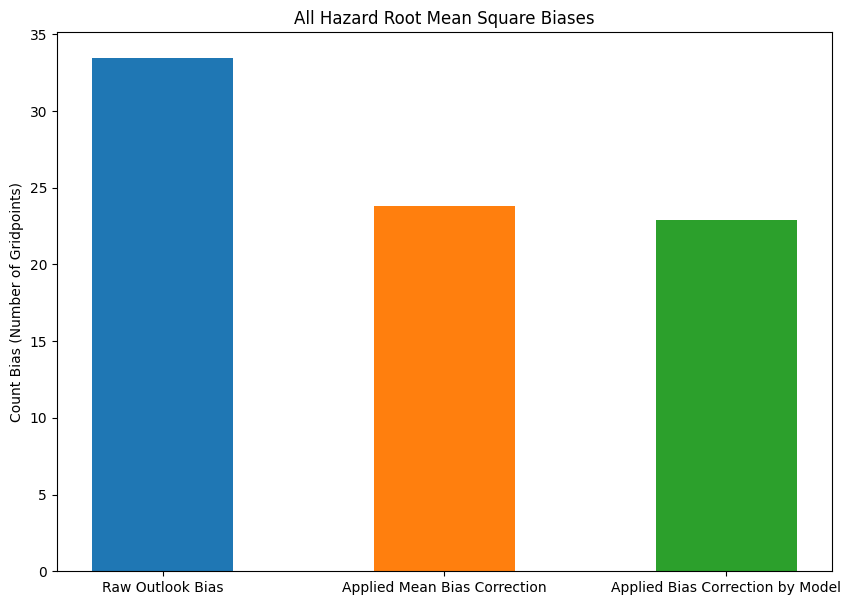

<Figure size 640x480 with 0 Axes>

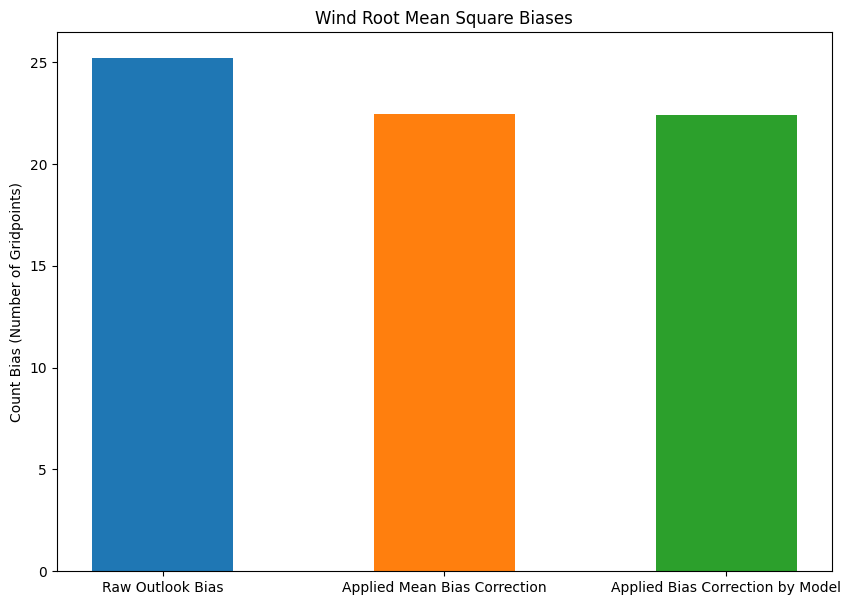

<Figure size 640x480 with 0 Axes>

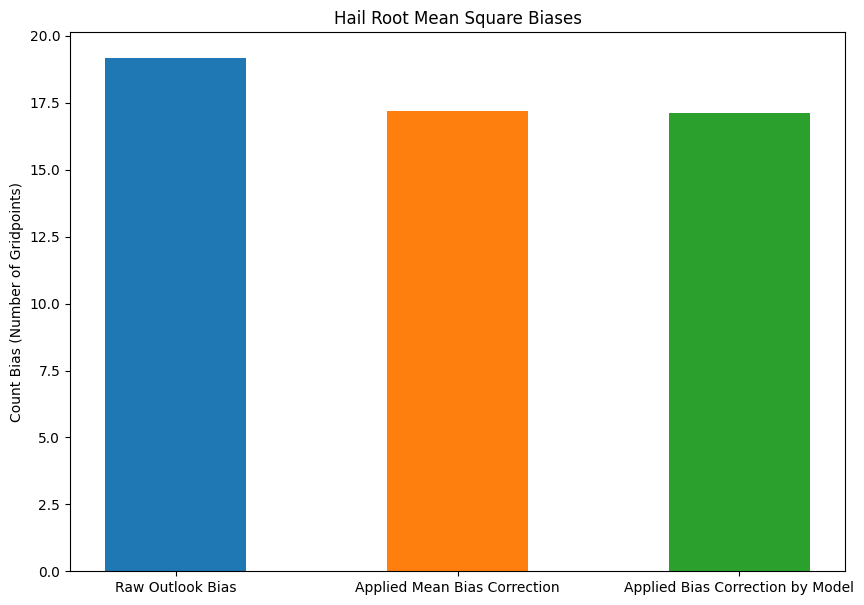

<Figure size 640x480 with 0 Axes>

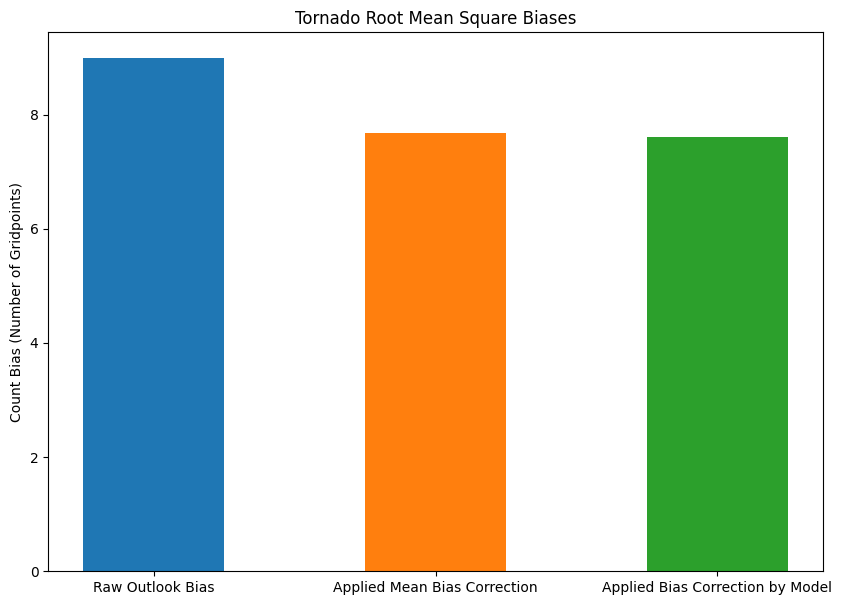

<Figure size 640x480 with 0 Axes>

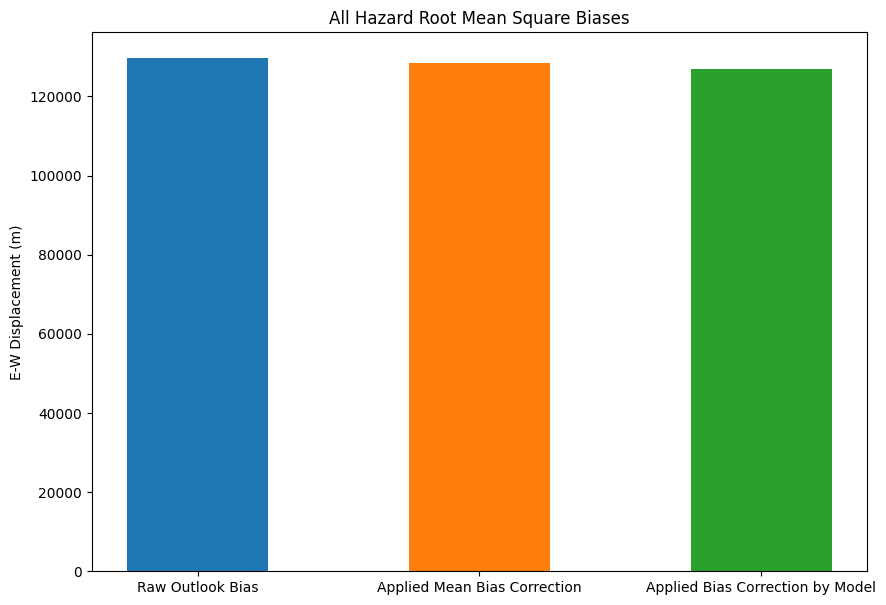

<Figure size 640x480 with 0 Axes>

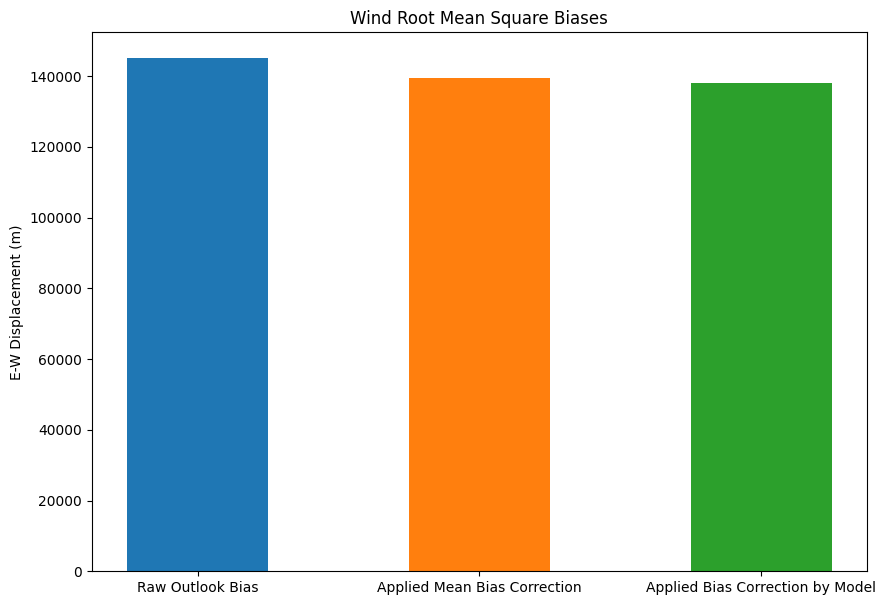

<Figure size 640x480 with 0 Axes>

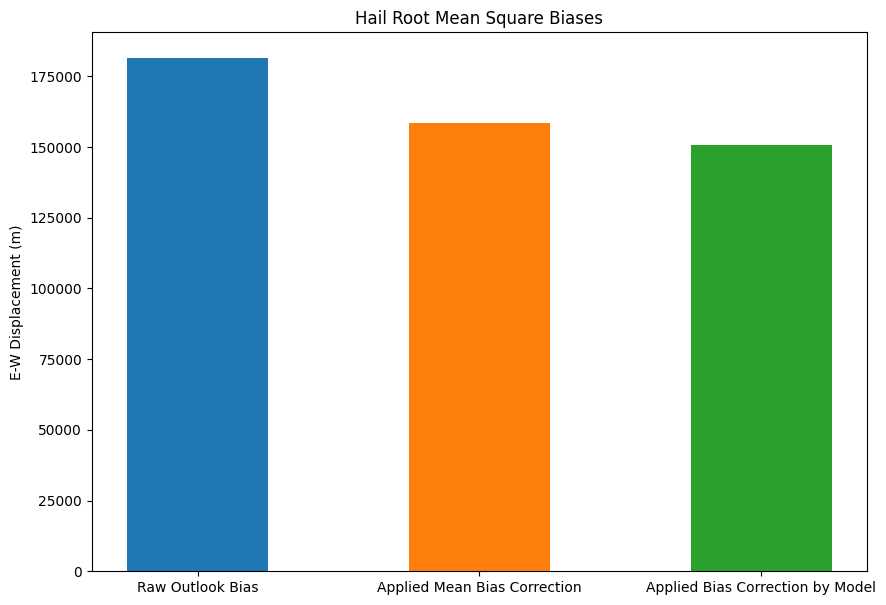

<Figure size 640x480 with 0 Axes>

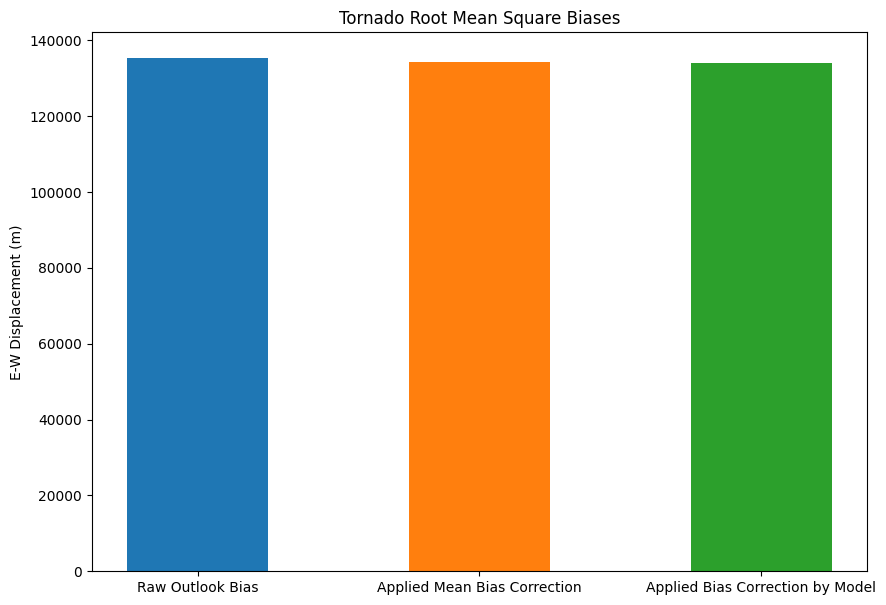

<Figure size 640x480 with 0 Axes>

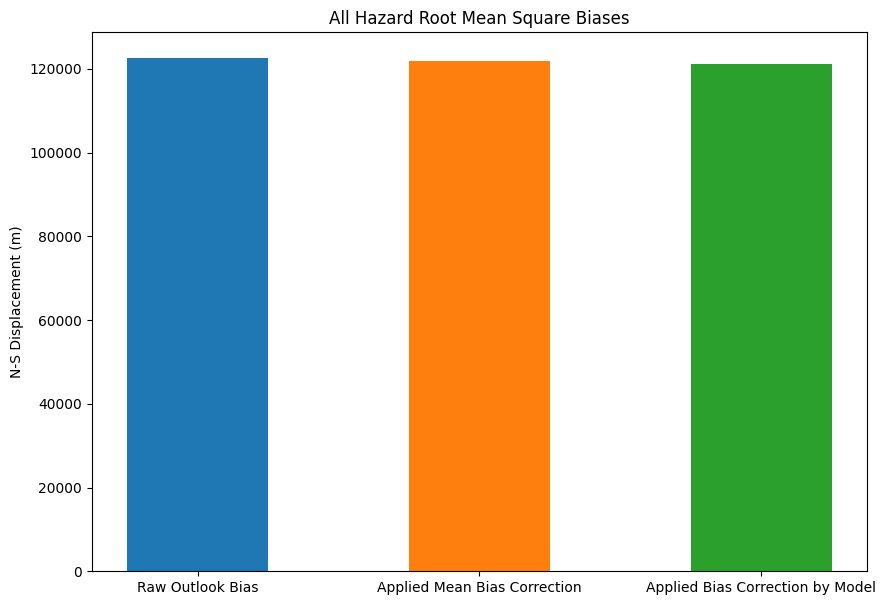

<Figure size 640x480 with 0 Axes>

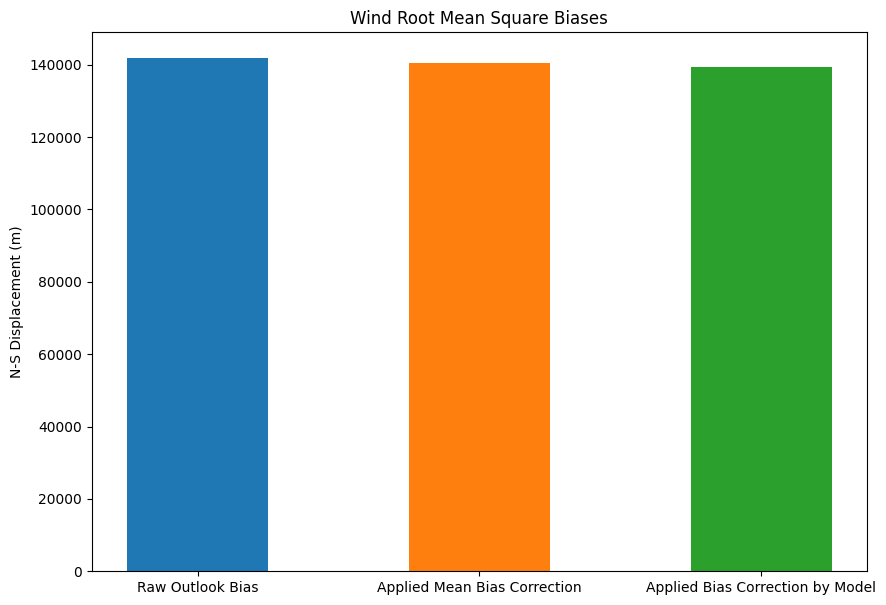

<Figure size 640x480 with 0 Axes>

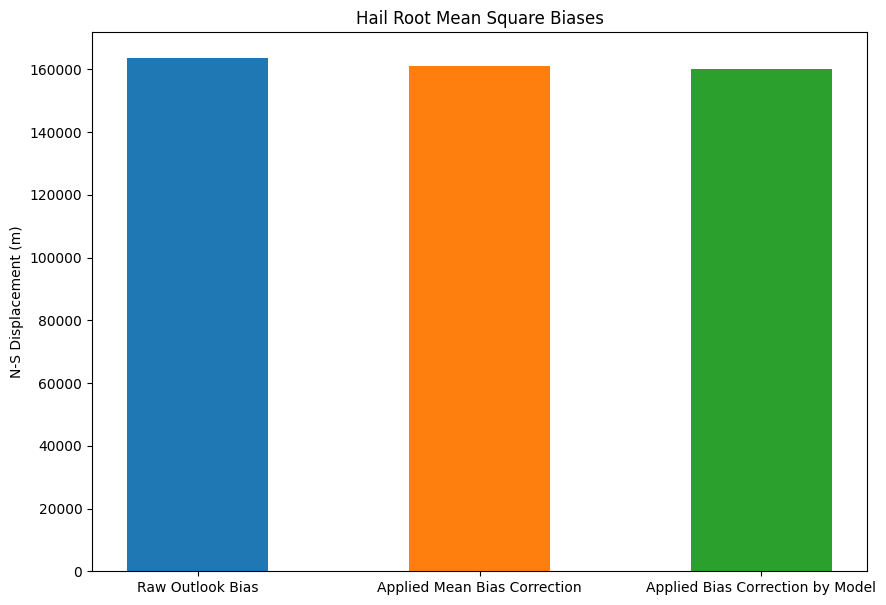

<Figure size 640x480 with 0 Axes>

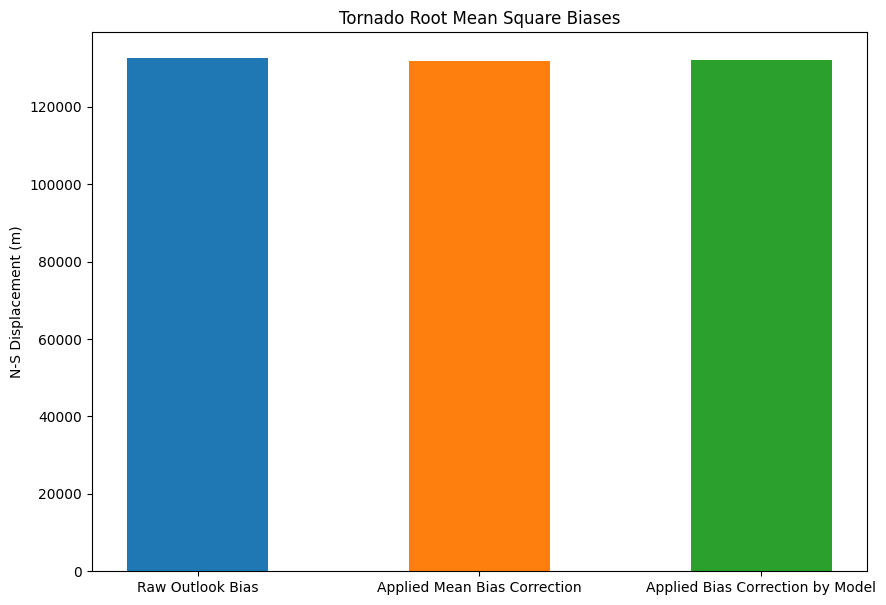

<Figure size 640x480 with 0 Axes>

In [ ]:
bar_labels = ['Raw Outlook Bias', 'Applied Mean Bias Correction', 'Applied Bias Correction by Model']
bar_positions = [0, 1, 2]
bar_width = 0.5

for i in range(12):
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.bar(bar_positions[0], rmses_units.iloc[5, i+1], width=bar_width)
    ax.bar(bar_positions[1], rmses_units.iloc[4, i+1], width=bar_width)
    ax.bar(bar_positions[2], rmses_units.iloc[1, i+1], width=bar_width)
    
    ax.set_xticks(bar_positions)
    ax.set_xticklabels(bar_labels)

    if i < 4:
        ax.set_ylabel('Count Bias (Number of Gridpoints)')
    
    elif i < 8: 
        ax.set_ylabel('E-W Displacement (m)')

    else:
        ax.set_ylabel('N-S Displacement (m)')

    if i%4 == 0:
        t = 'All Hazard'

    elif i%4 == 1:
        t = 'Wind'
        
    elif i%4 == 2:
        t = 'Hail'

    elif i%4 == 3:
        t = 'Tornado'

    ax.set_title(t + " Root Mean Square Biases")
    plt.show()
    plt.clf()

# TODO: one figure per bias type: stack all three bars below on top of each other (each starting at the bottom and ending at the height they do now), then 4 hazard types can be 4 bars